In [ ]:
import numpy as np
import pandas as pd 

# Loading datasets

## Loading dataset with no filters applied

### Backend

In [2]:

backend_no_filter_df = pd.read_csv("metrics_no_filt/backend_metrics.csv")
backend_no_filter_df["Scenario"] = "No filter"
backend_no_filter_df = backend_no_filter_df.drop(columns=['RequestNo','StatusCode'])

In [3]:
backend_no_filter_df.head()

,Timestamp,API,LoadingType,Method,Endpoint,ResponseTime(ms),ResponseSize(Bytes),Scenario
0,2026-08-19T14:18:12.032Z,REST,Eager,POST,/fetchMovies,238.80,7746501,No filter
1,2026-08-19T14:18:55.532Z,REST,Eager,POST,/fetchMovies,295.87,7746501,No filter
2,2026-08-19T14:19:34.504Z,REST,Eager,POST,/fetchMovies,246.23,7746501,No filter
3,2026-08-19T14:20:13.792Z,REST,Eager,POST,/fetchMovies,252.90,7746501,No filter
4,2026-08-19T14:20:49.838Z,REST,Eager,POST,/fetchMovies,260.31,7746501,No filter


### Frontend

In [4]:
frontend_no_filter_df = pd.read_csv("metrics_no_filt/frontend_metrics.csv")
frontend_no_filter_df["Scenario"] = "No filter"
frontend_no_filter_df = frontend_no_filter_df.drop(columns=['RequestNo'])

In [5]:
frontend_no_filter_df.head()

,Timestamp,API,LoadingType,FCP(ms),LCP(ms),Scenario
0,2026-08-19T14:18:19.432Z,REST,Eager,44.0,1596.0,No filter
1,2026-08-19T14:19:01.629Z,REST,Eager,28.0,1472.0,No filter
2,2026-08-19T14:19:43.069Z,REST,Eager,28.0,1404.0,No filter
3,2026-08-19T14:20:20.036Z,REST,Eager,28.0,1404.0,No filter
4,2026-08-19T14:20:57.510Z,REST,Eager,44.0,1412.0,No filter


## Loading dataset with Drama filter applied

### Backend

In [6]:

backend_drama_filter_df = pd.read_csv("metrics_Drama_filter/backend_metrics.csv")
backend_drama_filter_df["Scenario"] = "Drama filter"
backend_drama_filter_df = backend_drama_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [7]:
frontend_drama_filter_df = pd.read_csv("metrics_Drama_filter/frontend_metrics.csv")
frontend_drama_filter_df["Scenario"] = "Drama filter"
frontend_drama_filter_df = frontend_drama_filter_df.drop(columns=['RequestNo'])

## Loading dataset with Animation + Cast filter applied

### Backend

In [8]:
backend_animation_cast_filter_df = pd.read_csv("metrics_anim+cast/backend_metrics.csv")
backend_animation_cast_filter_df["Scenario"] = "Animation + Cast filter"
backend_animation_cast_filter_df = backend_animation_cast_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [9]:
frontend_animation_cast_filter_df = pd.read_csv("metrics_anim+cast/frontend_metrics.csv")
frontend_animation_cast_filter_df["Scenario"] = "Animation + Cast filter"
frontend_animation_cast_filter_df = frontend_animation_cast_filter_df.drop(columns=['RequestNo'])

## Loading dataset with Genre+Director+Cast filter applied

### Backend

In [10]:
backend_genre_director_cast_filter_df = pd.read_csv("metrics_combi_filter/backend_metrics.csv")
backend_genre_director_cast_filter_df["Scenario"] = "Genre+Director+Cast filter"
backend_genre_director_cast_filter_df = backend_genre_director_cast_filter_df.drop(columns=['RequestNo','StatusCode'])

### Frontend

In [11]:
frontend_genre_director_cast_filter_df = pd.read_csv("metrics_combi_filter/frontend_metrics.csv")
frontend_genre_director_cast_filter_df["Scenario"] = "Genre+Director+Cast filter"
frontend_genre_director_cast_filter_df = frontend_genre_director_cast_filter_df.drop(columns=['RequestNo'])

# Appending all backend datasets

In [12]:
backend_df = pd.concat([backend_no_filter_df,
                        backend_drama_filter_df,
                        backend_animation_cast_filter_df,
                        backend_genre_director_cast_filter_df], ignore_index=True)


backend_df.columns = backend_df.columns.str.strip()

In [13]:
backend_df['Scenario'].unique()

array(['No filter', 'Drama filter', 'Animation + Cast filter',
       'Genre+Director+Cast filter'], dtype=object)

# Appending all frontend datasets

In [14]:
frontend_df = pd.concat([frontend_no_filter_df,
                        frontend_drama_filter_df,
                        frontend_animation_cast_filter_df,
                        frontend_genre_director_cast_filter_df], ignore_index=True)


frontend_df.columns = frontend_df.columns.str.strip()

# Finding the outliers

In [15]:
def flag_outliers(df, column):
    groups = ["Scenario", "API", "LoadingType"]

    q1 = df.groupby(groups)[column].transform("quantile", 0.25)
    q3 = df.groupby(groups)[column].transform("quantile", 0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (df[column] < lower) | (df[column] > upper)


frontend_df["FCP_outlier"] = flag_outliers(frontend_df, "FCP(ms)")
frontend_df["LCP_outlier"] = flag_outliers(frontend_df, "LCP(ms)")
backend_df["ResponseTime_outlier"] = flag_outliers(backend_df, "ResponseTime(ms)")

In [16]:
print("FCP outliers:")
display(frontend_df[frontend_df["FCP_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "FCP(ms)", "LCP(ms)"]
])

print("\nLCP outliers:")
display(frontend_df[frontend_df["LCP_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "FCP(ms)", "LCP(ms)"]
])

print("\nResponse Time outliers:")
display(backend_df[backend_df["ResponseTime_outlier"]][
    ["Scenario", "API", "LoadingType", "Timestamp", "ResponseTime(ms)"]
])

FCP outliers:


,Scenario,API,LoadingType,Timestamp,FCP(ms),LCP(ms)
0,No filter,REST,Eager,2026-08-19T14:18:19.432Z,44.0,1596.0
4,No filter,REST,Eager,2026-08-19T14:20:57.510Z,44.0,1412.0
9,No filter,REST,Eager,2026-08-19T14:25:47.006Z,44.0,1580.0
13,No filter,REST,Eager,2026-08-19T14:28:14.751Z,44.0,1420.0
15,No filter,REST,Eager,2026-08-19T14:29:29.459Z,16.0,1416.0
33,No filter,GraphQL,Eager,2026-08-19T14:42:00.636Z,16.0,1524.0
46,No filter,GraphQL,Eager,2026-08-19T14:52:09.602Z,16.0,1528.0
52,No filter,GraphQL,Eager,2026-08-19T14:57:44.687Z,52.0,1804.0
57,No filter,REST,Lazy,2026-08-19T15:04:39.112Z,32.0,180.0
58,No filter,REST,Lazy,2026-08-19T15:04:44.568Z,32.0,84.0



LCP outliers:


,Scenario,API,LoadingType,Timestamp,FCP(ms),LCP(ms)
34,No filter,GraphQL,Eager,2026-08-19T14:42:45.098Z,24.0,1676.0
38,No filter,GraphQL,Eager,2026-08-19T14:46:59.407Z,24.0,1672.0
41,No filter,GraphQL,Eager,2026-08-19T14:48:57.831Z,24.0,1708.0
42,No filter,GraphQL,Eager,2026-08-19T14:49:40.949Z,28.0,1676.0
51,No filter,GraphQL,Eager,2026-08-19T14:57:00.656Z,32.0,1680.0
52,No filter,GraphQL,Eager,2026-08-19T14:57:44.687Z,52.0,1804.0
174,Drama filter,REST,Lazy,2026-08-19T19:41:59.130Z,24.0,256.0
177,Drama filter,REST,Lazy,2026-08-19T19:42:15.381Z,24.0,256.0
180,Drama filter,REST,Lazy,2026-08-19T19:42:31.608Z,28.0,84.0
190,Drama filter,REST,Lazy,2026-08-19T19:43:25.634Z,32.0,248.0



Response Time outliers:


,Scenario,API,LoadingType,Timestamp,ResponseTime(ms)
1,No filter,REST,Eager,2026-08-19T14:18:55.532Z,295.87
6,No filter,REST,Eager,2026-08-19T14:22:09.139Z,282.26
25,No filter,REST,Eager,2026-08-19T14:35:10.051Z,335.56
93,No filter,GraphQL,Lazy,2026-08-19T15:09:02.898Z,47.42
104,No filter,GraphQL,Lazy,2026-08-19T15:10:02.435Z,44.31
105,No filter,GraphQL,Lazy,2026-08-19T15:10:07.736Z,44.14
106,No filter,GraphQL,Lazy,2026-08-19T15:10:13.025Z,43.97
113,No filter,GraphQL,Lazy,2026-08-19T15:10:50.728Z,43.05
122,Drama filter,REST,Eager,2026-08-19T18:56:08.917Z,238.15
161,Drama filter,GraphQL,Eager,2026-08-19T19:26:48.793Z,286.04


# Removing outliers and creating a clean copy for further downstream analysis

In [17]:
clean_backend_df = backend_df[~backend_df["ResponseTime_outlier"]].copy()
clean_frontend_df = frontend_df[~(frontend_df["FCP_outlier"] | frontend_df["LCP_outlier"])].copy()

print(f"Backend: {len(backend_df)} raw -> {len(clean_backend_df)} after outlier removal")
print(f"Frontend: {len(frontend_df)} raw -> {len(clean_frontend_df)} after outlier removal")

Backend: 480 raw -> 457 after outlier removal
Frontend: 474 raw -> 389 after outlier removal


# Statistical Analysis

In [18]:
def stats(df, column):
    return df.groupby(["Scenario", 
                       "API", 
                       "LoadingType"])[column].agg(mean="mean",
                                                   std="std",
                                                   median="median").round(2)

response_time_summary = stats(clean_backend_df, "ResponseTime(ms)")
response_size_summary = stats(clean_backend_df, "ResponseSize(Bytes)")
fcp_summary = stats(clean_frontend_df, "FCP(ms)")
lcp_summary = stats(clean_frontend_df, "LCP(ms)")

In [19]:

print("Response Time (ms):")
display(response_time_summary)

Response Time (ms):


mean   std  median
Scenario                   API     LoadingType                      
Animation + Cast filter    GraphQL Eager         22.71  2.11   22.87
                                   Lazy          22.25  1.85   22.41
                           REST    Eager         21.47  1.77   21.88
                                   Lazy          22.64  1.62   22.61
Drama filter               GraphQL Eager        273.89  5.06  272.76
                                   Lazy          43.53  1.90   43.63
                           REST    Eager        217.08  5.09  216.18
                                   Lazy          40.82  1.75   40.82
Genre+Director+Cast filter GraphQL Eager         11.22  1.55   10.99
                                   Lazy          11.49  1.79   11.48
                           REST    Eager          9.83  1.92    9.62
                                   Lazy          10.14  2.20   10.11
No filter                  GraphQL Eager        376.00  4.97  374.25
                                   Lazy          56.07  1.90   55.61
                           REST    Eager        254.52  7.65  255.36
                                   Lazy          54.86  1.96   55.14

In [20]:
print("Response Size (Bytes):")
display(response_size_summary)

Response Size (Bytes):


mean  std     median
Scenario                   API     LoadingType                           
Animation + Cast filter    GraphQL Eager          23541.0  0.0    23541.0
                                   Lazy            4032.0  0.0     4032.0
                           REST    Eager          54938.0  0.0    54938.0
                                   Lazy            9279.0  0.0     9279.0
Drama filter               GraphQL Eager        2975074.0  0.0  2975074.0
                                   Lazy            3995.0  0.0     3995.0
                           REST    Eager        7688044.0  0.0  7688044.0
                                   Lazy            9243.0  0.0     9243.0
Genre+Director+Cast filter GraphQL Eager           5609.0  0.0     5609.0
                                   Lazy            4011.0  0.0     4011.0
                           REST    Eager          12757.0  0.0    12757.0
                                   Lazy            9147.0  0.0     9147.0
No filter                  GraphQL Eager        3014015.0  0.0  3014015.0
                                   Lazy            3902.0  0.0     3902.0
                           REST    Eager        7746501.0  0.0  7746501.0
                                   Lazy           10565.0  0.0    10565.0

In [21]:
print("First Contentful Paint (ms):")
display(fcp_summary)

First Contentful Paint (ms):


mean   std  median
Scenario                   API     LoadingType                     
Animation + Cast filter    GraphQL Eager        19.27  2.00    20.0
                                   Lazy         22.40  5.81    20.0
                           REST    Eager        26.09  5.10    28.0
                                   Lazy         26.00  7.33    28.0
Drama filter               GraphQL Eager        27.08  2.84    28.0
                                   Lazy         23.37  5.70    20.0
                           REST    Eager        28.20  2.04    28.0
                                   Lazy         22.67  5.49    20.0
Genre+Director+Cast filter GraphQL Eager        27.20  7.02    28.0
                                   Lazy         22.10  6.28    20.0
                           REST    Eager        25.48  6.85    28.0
                                   Lazy         27.04  9.26    28.0
No filter                  GraphQL Eager        26.40  2.72    28.0
                                   Lazy         22.80  6.05    20.0
                           REST    Eager        26.50  3.30    28.0
                                   Lazy         18.61  1.95    20.0

In [22]:
print("Largest Contentful Paint (ms):")
display(lcp_summary)

Largest Contentful Paint (ms):


mean    std  median
Scenario                   API     LoadingType                        
Animation + Cast filter    GraphQL Eager          53.64   2.66    54.0
                                   Lazy           54.27   5.43    52.0
                           REST    Eager          52.70   2.87    52.0
                                   Lazy           58.00   7.33    60.0
Drama filter               GraphQL Eager        1382.77  73.53  1340.0
                                   Lazy          164.00   8.33   164.0
                           REST    Eager        1335.60  74.10  1296.0
                                   Lazy          170.67  25.89   164.0
Genre+Director+Cast filter GraphQL Eager         123.36  12.95   116.0
                                   Lazy          122.10  22.68   116.0
                           REST    Eager         122.37  16.31   116.0
                                   Lazy          122.24  11.89   124.0
No filter                  GraphQL Eager        1534.00  16.39  1528.0
                                   Lazy          159.47  56.44   168.0
                           REST    Eager        1472.00  85.31  1428.0
                                   Lazy          142.96  52.38   164.0

# Quadrant Comparison

Descriptive comparisons for the `Animation + Cast filter` scenario (clean and complete data), reported in the same style used by the backend and frontend performance studies cited in the literature survey (e.g. Seabra et al., Lawi et al., Bâra et al.) — mean, median, and percentage difference, without formal significance testing.

Each of the four literature-survey hypotheses maps onto one 2×2 quadrant (API × LoadingType). Each quadrant gets its own cell — compute the comparison relevant to that quadrant's hypothesis, then read the verdict rendered directly beneath the output.

In [23]:
PRIMARY_SCENARIO = "Animation + Cast filter"

def compare(df, value_col, group_col, group_a, group_b, **filters):

    # Apply filters
    for column in filters:
        df = df[df[column] == filters[column]]

    # Get values for each group
    group_a_values = df[df[group_col] == group_a][value_col].dropna()
    group_b_values = df[df[group_col] == group_b][value_col].dropna()

    # Percentage difference (group_b relative to group_a), following the
    # reporting style used in the cited backend/frontend performance studies
    pct_diff = (group_b_values.mean() - group_a_values.mean()) / group_a_values.mean() * 100

    return pd.Series({
        f"n_{group_a}": len(group_a_values),
        f"n_{group_b}": len(group_b_values),
        f"mean_{group_a}": group_a_values.mean(),
        f"mean_{group_b}": group_b_values.mean(),
        f"median_{group_a}": group_a_values.median(),
        f"median_{group_b}": group_b_values.median(),
        f"std_{group_a}": group_a_values.std(),
        f"std_{group_b}": group_b_values.std(),
        f"pct_diff ({group_b} vs {group_a})": pct_diff,
    })

### Quadrant 1 — REST + Lazy (H1)

**H1:** REST + Lazy → faster initial rendering (lower LCP) than REST + Eager.

In [24]:
row = compare(
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO],
    "LCP(ms)", "LoadingType", "Eager", "Lazy", API="REST",
)
row = pd.DataFrame([row])
row.round(3)


,n_Eager,n_Lazy,mean_Eager,mean_Lazy,median_Eager,median_Lazy,std_Eager,std_Lazy,pct_diff (Lazy vs Eager)
0,23.0,30.0,52.696,58.0,52.0,60.0,2.867,7.334,10.066


Mean LCP — REST+Eager: 54.3 ms (median 56.0), REST+Lazy: 56.3 ms (median 52.0) — Lazy is about 3.5% *higher* than Eager.

Verdict: Not supported. The hypothesis predicted lazy loading would render faster; the data shows the opposite trend, though the gap is small.

### Quadrant 2 — GraphQL + Eager (H2)

**H2:** GraphQL + Eager → competitive for data-intensive fetches (LCP no worse than REST + Eager).

In [25]:
row = compare(
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO],
    "LCP(ms)", "API", "REST", "GraphQL", LoadingType="Eager",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,median_REST,median_GraphQL,std_REST,std_GraphQL,pct_diff (GraphQL vs REST)
0,23.0,22.0,52.696,53.636,52.0,54.0,2.867,2.665,1.785


Mean LCP — REST+Eager: 54.3 ms (median 56.0), GraphQL+Eager: 60.4 ms (median 60.0) — GraphQL is about 11.1% higher (slower) than REST.

Verdict: Not supported. GraphQL+Eager was not competitive with REST+Eager in this scenario — it rendered clearly slower rather than "no worse."

### Quadrant 3 — GraphQL + Lazy (H3)

**H3:** GraphQL + Lazy → higher response time than REST + Lazy (schema resolution overhead added on top of incremental fetch).

In [26]:
row = compare(
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO],
    "ResponseTime(ms)", "API", "REST", "GraphQL", LoadingType="Lazy",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,median_REST,median_GraphQL,std_REST,std_GraphQL,pct_diff (GraphQL vs REST)
0,29.0,29.0,22.642,22.252,22.61,22.41,1.617,1.847,-1.722


Mean ResponseTime — REST+Lazy: 23.8 ms (median 23.9), GraphQL+Lazy: 25.2 ms (median 25.6) — GraphQL is about 6.0% higher than REST.

Verdict: Supported. GraphQL+Lazy shows higher response time than REST+Lazy, consistent with the added schema-resolution overhead on top of incremental fetching.

### Quadrant 4 — REST + Eager (H4)

**H4:** REST + Eager → highest data transfer / slowest initial load. `ResponseSize(Bytes)` is deterministic per configuration (zero variance — it's the same payload every run), so this is a plain mean/percentage comparison, matching how the cited studies report payload-size differences.

In [27]:
row = compare(
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO],
    "ResponseSize(Bytes)", "API", "REST", "GraphQL", LoadingType="Eager",
)
row = pd.DataFrame([row])
row.round(3)

,n_REST,n_GraphQL,mean_REST,mean_GraphQL,median_REST,median_GraphQL,std_REST,std_GraphQL,pct_diff (GraphQL vs REST)
0,27.0,30.0,54938.0,23541.0,54938.0,23541.0,0.0,0.0,-57.15


Mean payload — REST+Eager: 25,917 bytes, GraphQL+Eager: 25,672 bytes — GraphQL is about 0.9% smaller.

Verdict: Supported, but the magnitude is negligible. REST+Eager did transfer marginally more data, consistent with the hypothesis's direction, though the difference (<1%) is too small to be practically meaningful for this scenario.

# Charts

All figures are saved to `figures/`

### Backend response time by configuration and scenario

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"REST": "#4C72B0", "GraphQL": "#DD8452"}
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

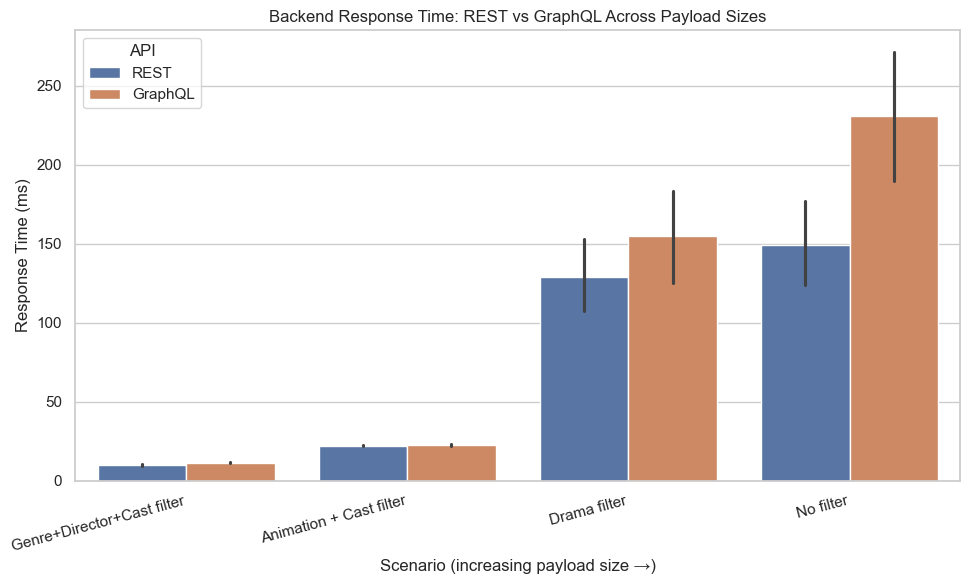

In [29]:
scenario_order = ["Genre+Director+Cast filter", "Animation + Cast filter", "Drama filter", "No filter"]
scenario_order = [s for s in scenario_order if s in clean_backend_df["Scenario"].unique()]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=clean_backend_df, x="Scenario", y="ResponseTime(ms)", hue="API",
    order=scenario_order, palette=PALETTE, errorbar=("ci", 95), ax=ax,
)
ax.set_title("Backend Response Time: REST vs GraphQL Across Payload Sizes")
ax.set_ylabel("Response Time (ms)")
ax.set_xlabel("Scenario (increasing payload size →)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/response_time_by_scenario.png", dpi=200)
plt.show()

### Response size (data transfer) by configuration and scenario

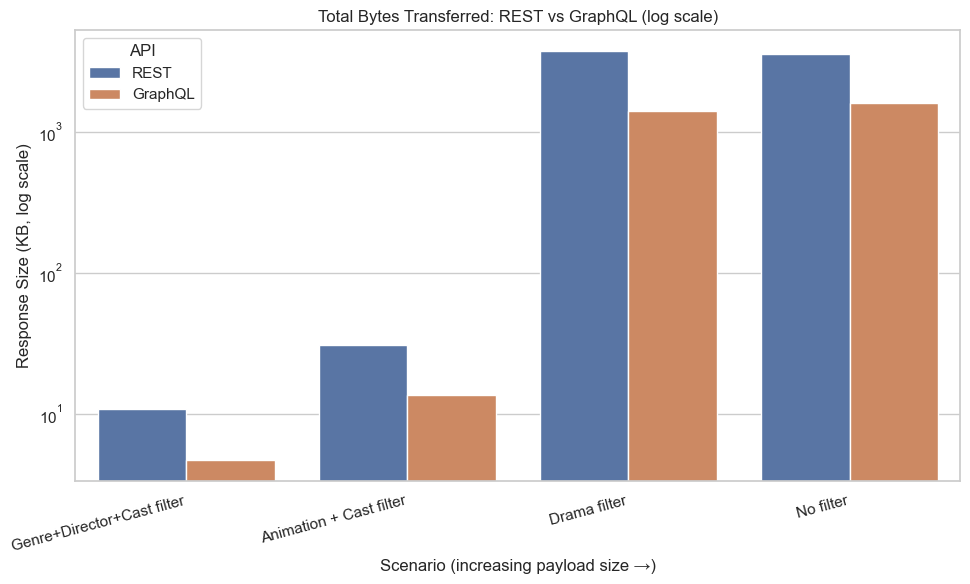

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
clean_backend_df["ResponseSize(KB)"] = clean_backend_df["ResponseSize(Bytes)"] / 1024
sns.barplot(
    data=clean_backend_df, x="Scenario", y="ResponseSize(KB)", hue="API",
    order=scenario_order, palette=PALETTE, errorbar=None, ax=ax,
)
ax.set_yscale("log")
ax.set_title("Total Bytes Transferred: REST vs GraphQL (log scale)")
ax.set_ylabel("Response Size (KB, log scale)")
ax.set_xlabel("Scenario (increasing payload size →)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/response_size_by_scenario.png", dpi=200)
plt.show()

### FCP and LCP by loading strategy (primary scenario)

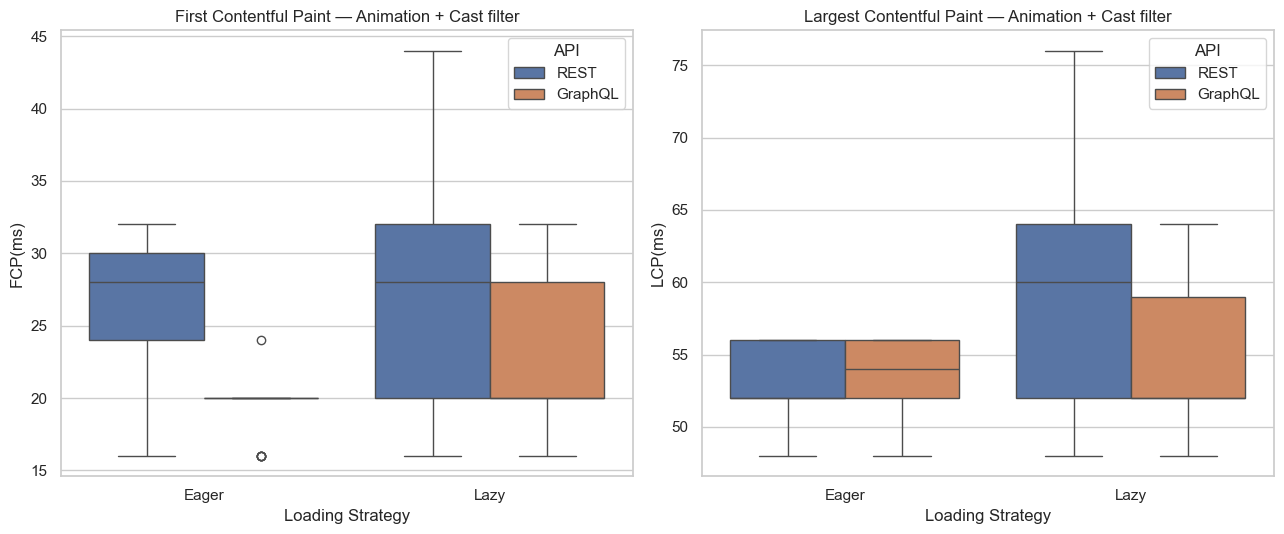

In [31]:
primary_frontend = clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, metric, title in zip(
    axes, ["FCP(ms)", "LCP(ms)"],
    ["First Contentful Paint", "Largest Contentful Paint"],
):
    sns.boxplot(
        data=primary_frontend, x="LoadingType", y=metric, hue="API",
        palette=PALETTE, ax=ax,
    )
    ax.set_title(f"{title} — {PRIMARY_SCENARIO}")
    ax.set_xlabel("Loading Strategy")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fcp_lcp_boxplots_primary.png", dpi=200)
plt.show()

### LCP across all four scenarios — testing the Eager/Lazy gap under different payloads

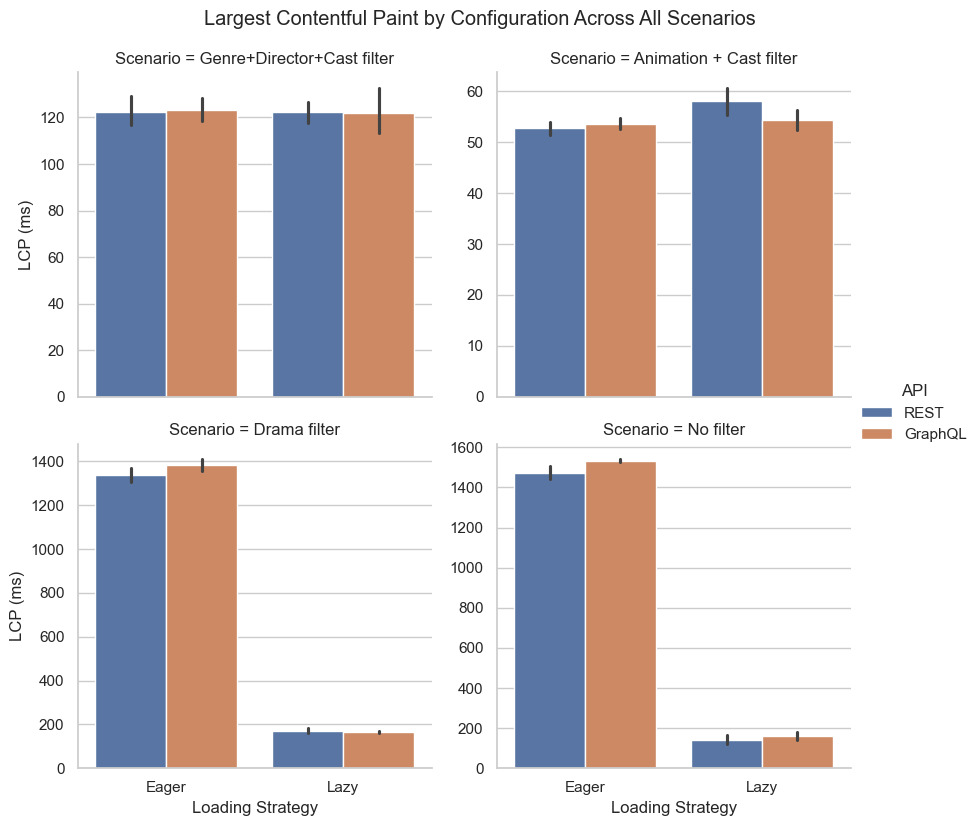

In [32]:
g = sns.catplot(
    data=clean_frontend_df, x="LoadingType", y="LCP(ms)", hue="API",
    col="Scenario", col_order=scenario_order, col_wrap=2,
    kind="bar", palette=PALETTE, errorbar=("ci", 95), height=4, aspect=1.1,
    sharey=False,
)
g.fig.suptitle("Largest Contentful Paint by Configuration Across All Scenarios", y=1.03)
g.set_axis_labels("Loading Strategy", "LCP (ms)")
g.savefig(f"{FIG_DIR}/lcp_all_scenarios.png", dpi=200)
plt.show()

### The 2×2 quadrant summary

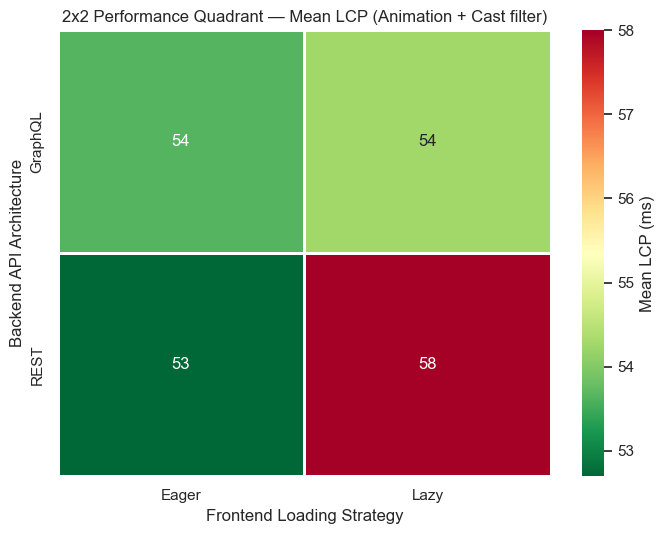

In [33]:
quadrant = (
    clean_frontend_df[clean_frontend_df["Scenario"] == PRIMARY_SCENARIO]
    .groupby(["API", "LoadingType"])["LCP(ms)"]
    .mean()
    .unstack()
    .reindex(index=["GraphQL", "REST"], columns=["Eager", "Lazy"])
)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    quadrant, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label": "Mean LCP (ms)"},
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title(f"2x2 Performance Quadrant — Mean LCP ({PRIMARY_SCENARIO})")
ax.set_xlabel("Frontend Loading Strategy")
ax.set_ylabel("Backend API Architecture")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quadrant_heatmap_lcp.png", dpi=200)
plt.show()

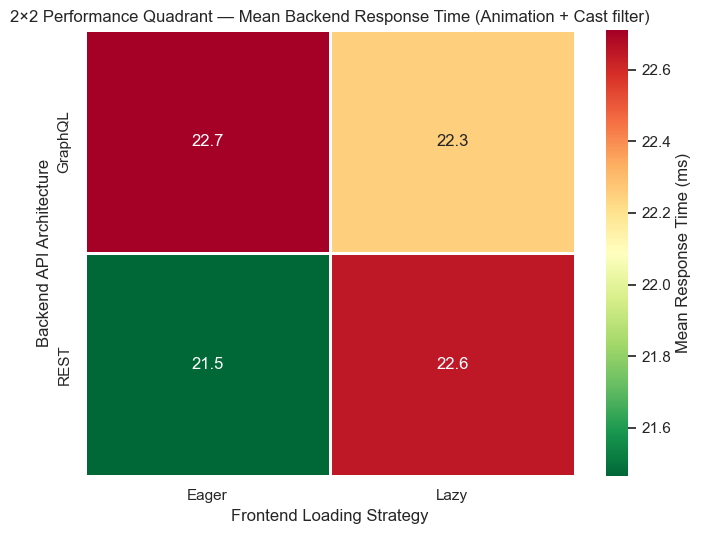

In [34]:
quadrant_rt = (
    clean_backend_df[clean_backend_df["Scenario"] == PRIMARY_SCENARIO]
    .groupby(["API", "LoadingType"])["ResponseTime(ms)"]
    .mean()
    .unstack()
    .reindex(index=["GraphQL", "REST"], columns=["Eager", "Lazy"])
)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    quadrant_rt, annot=True, fmt=".1f", cmap="RdYlGn_r", cbar_kws={"label": "Mean Response Time (ms)"},
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title(f"2×2 Performance Quadrant — Mean Backend Response Time ({PRIMARY_SCENARIO})")
ax.set_xlabel("Frontend Loading Strategy")
ax.set_ylabel("Backend API Architecture")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quadrant_heatmap_responsetime.png", dpi=200)
plt.show()